In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("leftin/fruit-ripeness-unripe-ripe-and-rotten")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fruit-ripeness-unripe-ripe-and-rotten


In [ ]:
import os
import torch
import numpy as np
from glob import glob
from PIL import Image
from torch.utils.data import random_split, Dataset, DataLoader
from torchvision import transforms as T

torch.manual_seed(2025)

class CustomDataset(Dataset):
    def __init__(self, root, data_type, transformations=None, im_files=[".png", ".jpg"]):

        self.transformations = transformations
        self.root = root # Store root to determine relative path for class
        self.data_type = data_type

        # Modified glob pattern to search recursively from the root
        self.im_paths = []
        for im_file in im_files:
             self.im_paths.extend(glob(f"{root}/**/*{im_file}", recursive=True))

        # Filter paths based on data_type (train or test) if the dataset structure
        # has these directories directly under root. If not, the filtering logic
        # might need further adjustment based on actual directory structure.
        # Assuming the structure is like root/train/class/image.jpg
        self.im_paths = [p for p in self.im_paths if f"/{self.data_type}/" in p]


        # Add a print statement to check how many images are found after filtering
        print(f"Found {len(self.im_paths)} images for data_type: {data_type}")


        self.cls_names, self.cls_counts = {}, {}
        count = 0
        for im_path in self.im_paths:
            class_name = self.get_class(im_path)
            if class_name not in self.cls_names:
                self.cls_names[class_name] = count
                self.cls_counts[class_name] = 1
                count += 1
            else:
                self.cls_counts[class_name] += 1

    def get_class(self, path):
        # Get the directory name relative to the root, split by '/', and take the second to last element
        # This assumes the structure is like root/train/class/image.jpg or root/test/class/image.jpg
        try:
            relative_path = os.path.relpath(os.path.dirname(path), self.root)
            class_name = relative_path.split(os.sep)[-1]
            return class_name
        except Exception as e:
            print(f"Error getting class for path {path}: {e}")
            return "unknown_class" # Handle cases where path might not fit expected structure


    def __len__(self): return len(self.im_paths)

    def __getitem__(self, idx):

        im_path = self.im_paths[idx]
        im = Image.open(im_path).convert("RGB")

        if self.transformations: im = self.transformations(im)
        gt = self.cls_names[self.get_class(im_path)]
        return im, gt


    @classmethod
    def get_dls(cls, root, transformations, bs, split=[0.9, 0.05, 0.05], ns=4):

        # Instantiate with the potentially corrected filtering logic within __init__
        tr_ds = cls(root=root, data_type="train", transformations=transformations)
        ts_ds = cls(root=root, data_type="test", transformations=transformations)
        cls_names, cls_counts = tr_ds.cls_names, tr_ds.cls_counts

        total_len = len(tr_ds)

        # Add a check for total_len before splitting
        if total_len == 0:
             raise ValueError(f"Training dataset is empty. Check the root path ({root}) and glob pattern.")

        tr_len = int(total_len * split[0])
        vl_len = total_len - tr_len

        # Ensure that both training and validation lengths are non-zero and the validation set is not too small
        if tr_len == 0 or vl_len < 1: # Changed vl_len == 0 to vl_len < 1
            raise ValueError(f"Dataset split resulted in an empty train set ({tr_len}) or insufficient validation set size ({vl_len}). Check dataset size and split ratios.")

        tr_ds, vl_ds = random_split(tr_ds, [tr_len, vl_len])

        tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=ns)
        val_dl = DataLoader(vl_ds, batch_size=bs, shuffle=False, num_workers=ns)
        ts_dl = DataLoader(ts_ds, batch_size=1, shuffle=False, num_workers=ns)

        # Ensure ts_dl is not empty if test data was found
        if len(ts_ds) == 0:
             print("Warning: Test dataset is empty.")


        return tr_dl, val_dl, ts_dl, cls_names, [cls_counts]

# Keep the rest of the code as is
root = "/root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/1"
mean, std, im_size, bs = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 64, 32
tfs = T.Compose([T.Resize((im_size, im_size)), T.ToTensor(), T.Normalize(mean=mean, std=std)])

# This call will now use the modified CustomDataset
tr_dl, val_dl, ts_dl, classes, cls_counts = CustomDataset.get_dls(root=root, transformations=tfs, bs=bs)
print(len(tr_dl)); print(len(val_dl)); print(len(ts_dl)); print(classes)

Found 34158 images for data_type: train
Found 7778 images for data_type: test
961
107
7778
{'rottenoranges': 0, 'freshoranges': 1, 'rottenapples': 2, 'rottenbanana': 3, 'freshbanana': 4, 'freshapples': 5, 'unripe orange': 6, 'unripe apple': 7, 'unripe banana': 8}


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Data analysis is in process...



<ipython-input-5-45f3dfeb235d>:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cls_names, rotation = 90)


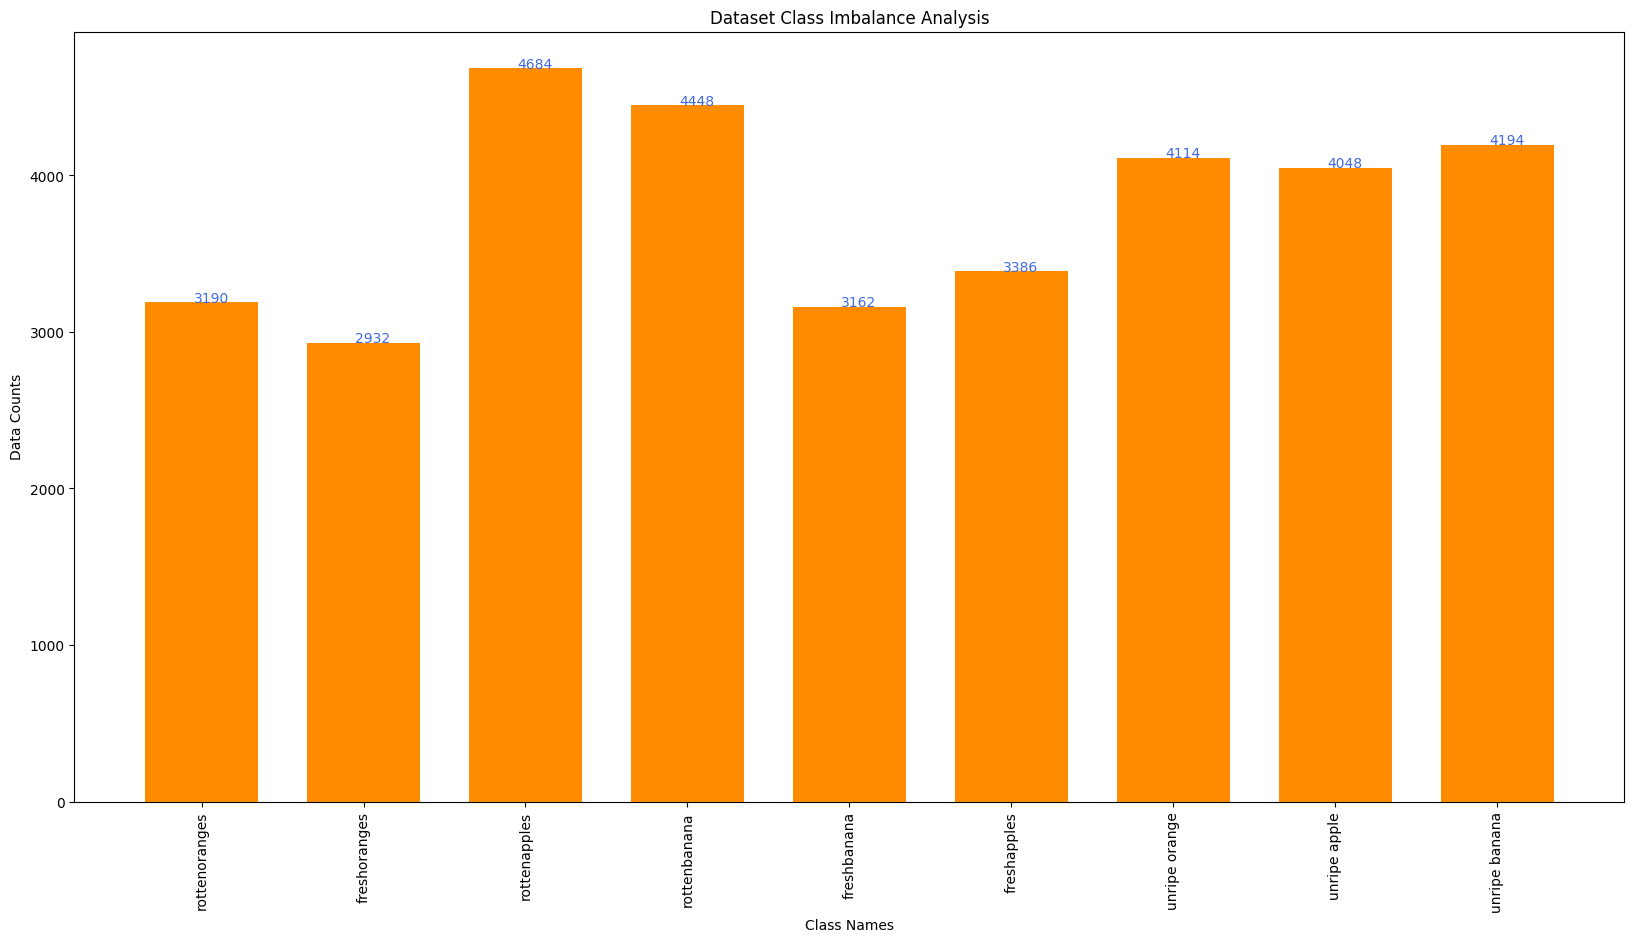

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from torchvision import transforms as T

class Visualization:

    def __init__(self, vis_datas, n_ims, rows, cmap=None, cls_names=None, cls_counts=None, t_type="rgb"):
        self.n_ims, self.rows = n_ims, rows
        self.t_type, self.cmap = t_type, cmap
        self.cls_names = cls_names
        self.colors = ["darkorange", "seagreen", "salmon"]

        data_names = ["train", "val", "test"]
        self.vis_datas = {data_names[i]: vis_datas[i] for i in range(len(vis_datas))}
        if isinstance(cls_counts, list):
            self.analysis_datas = {data_names[i]: cls_counts[i] for i in range(len(cls_counts))}
        else:
            self.analysis_datas = {"all": cls_counts}

    def tn2np(self, t):
        gray_tfs = T.Compose([T.Normalize(mean=[0.], std=[1/0.5]), T.Normalize(mean=[-0.5], std=[1])])
        rgb_tfs = T.Compose([T.Normalize(mean=[0., 0., 0.], std=[1/0.229, 1/0.224, 1/0.225]),
                             T.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.])])

        invTrans = gray_tfs if self.t_type == "gray" else rgb_tfs

        return (invTrans(t) * 255).detach().squeeze().cpu().permute(1, 2, 0).numpy().astype(np.uint8) if self.t_type == "gray" \
               else (invTrans(t) * 255).detach().cpu().permute(1, 2, 0).numpy().astype(np.uint8)

    def plot(self, rows, cols, count, im, title="Original Image"):
        plt.subplot(rows, cols, count)
        plt.imshow(self.tn2np(im))
        plt.axis("off")
        plt.title(title)
        return count + 1

    def vis(self, data, save_name):
        print(f"{save_name.upper()} Data Visualization is in process...\n")
        assert self.cmap in ["rgb", "gray"], "Please choose rgb or gray cmap"
        cmap = "viridis" if self.cmap == "rgb" else None
        cols = self.n_ims // self.rows
        count = 1

        plt.figure(figsize=(25, 20))
        indices = [np.random.randint(low=0, high=len(data) - 1) for _ in range(self.n_ims)]

        for idx, index in enumerate(indices):
            if count == self.n_ims + 1: break
            image, label = data[index]
            plt.subplot(self.rows, self.n_ims // self.rows, idx + 1)

            if cmap:
                plt.imshow(self.tn2np(image), cmap=cmap)
            else:
                plt.imshow(self.tn2np(image))

            plt.axis('off')
            if self.cls_names is not None:
                plt.title(f"GT -> {self.cls_names[int(label)]}")
            else:
                plt.title(f"GT -> {label}")

        plt.show()

    def data_analysis(self, cls_counts, save_name, color):
        print("Data analysis is in process...\n")
        width, text_width, text_height = 0.7, 0.05, 2
        cls_names = list(cls_counts.keys())
        counts = list(cls_counts.values())
        _, ax = plt.subplots(figsize=(20, 10))
        indices = np.arange(len(counts))
        ax.bar(indices, counts, width, color=color)
        ax.set_xlabel("Class Names", color="black")
        ax.set_xticklabels(cls_names, rotation = 90)
        ax.set(xticks=indices, xticklabels=cls_names)
        ax.set_ylabel("Data Counts", color="black")
        ax.set_title("Dataset Class Imbalance Analysis")
        for i, v in enumerate(counts):
            ax.text(i - text_width, v + text_height, str(v), color="royalblue")

    def plot_pie_chart(self, cls_counts):
        print("Generating pie chart...\n")
        labels = list(cls_counts.keys())
        sizes = list(cls_counts.values())
        explode = [0.1] * len(labels)  # To highlight all slices equally (optional)

        plt.figure(figsize=(8, 8))
        plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
        plt.title("Class Distribution")
        plt.axis("equal")  # Equal aspect ratio ensures the pie chart is circular
        plt.show()

    def visualization(self): [self.vis(data.dataset, save_name) for (save_name, data) in self.vis_datas.items()]

    def analysis(self): [self.data_analysis(data, save_name, color) for (save_name, data), color in zip(self.analysis_datas.items(), self.colors)]

    def pie_chart(self): [self.plot_pie_chart(data) for data in self.analysis_datas.values()]

vis = Visualization(vis_datas = [tr_dl, ts_dl], n_ims = 18, rows = 6, cmap = "rgb", cls_names = list(classes.keys()), cls_counts = cls_counts)
vis.analysis()

Generating pie chart...



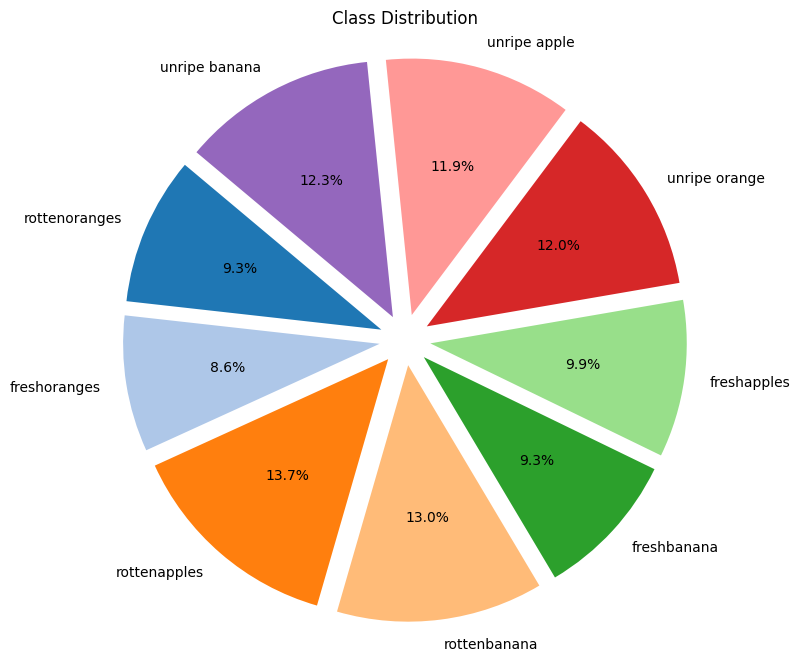

In [ ]:
vis.pie_chart()

TRAIN Data Visualization is in process...



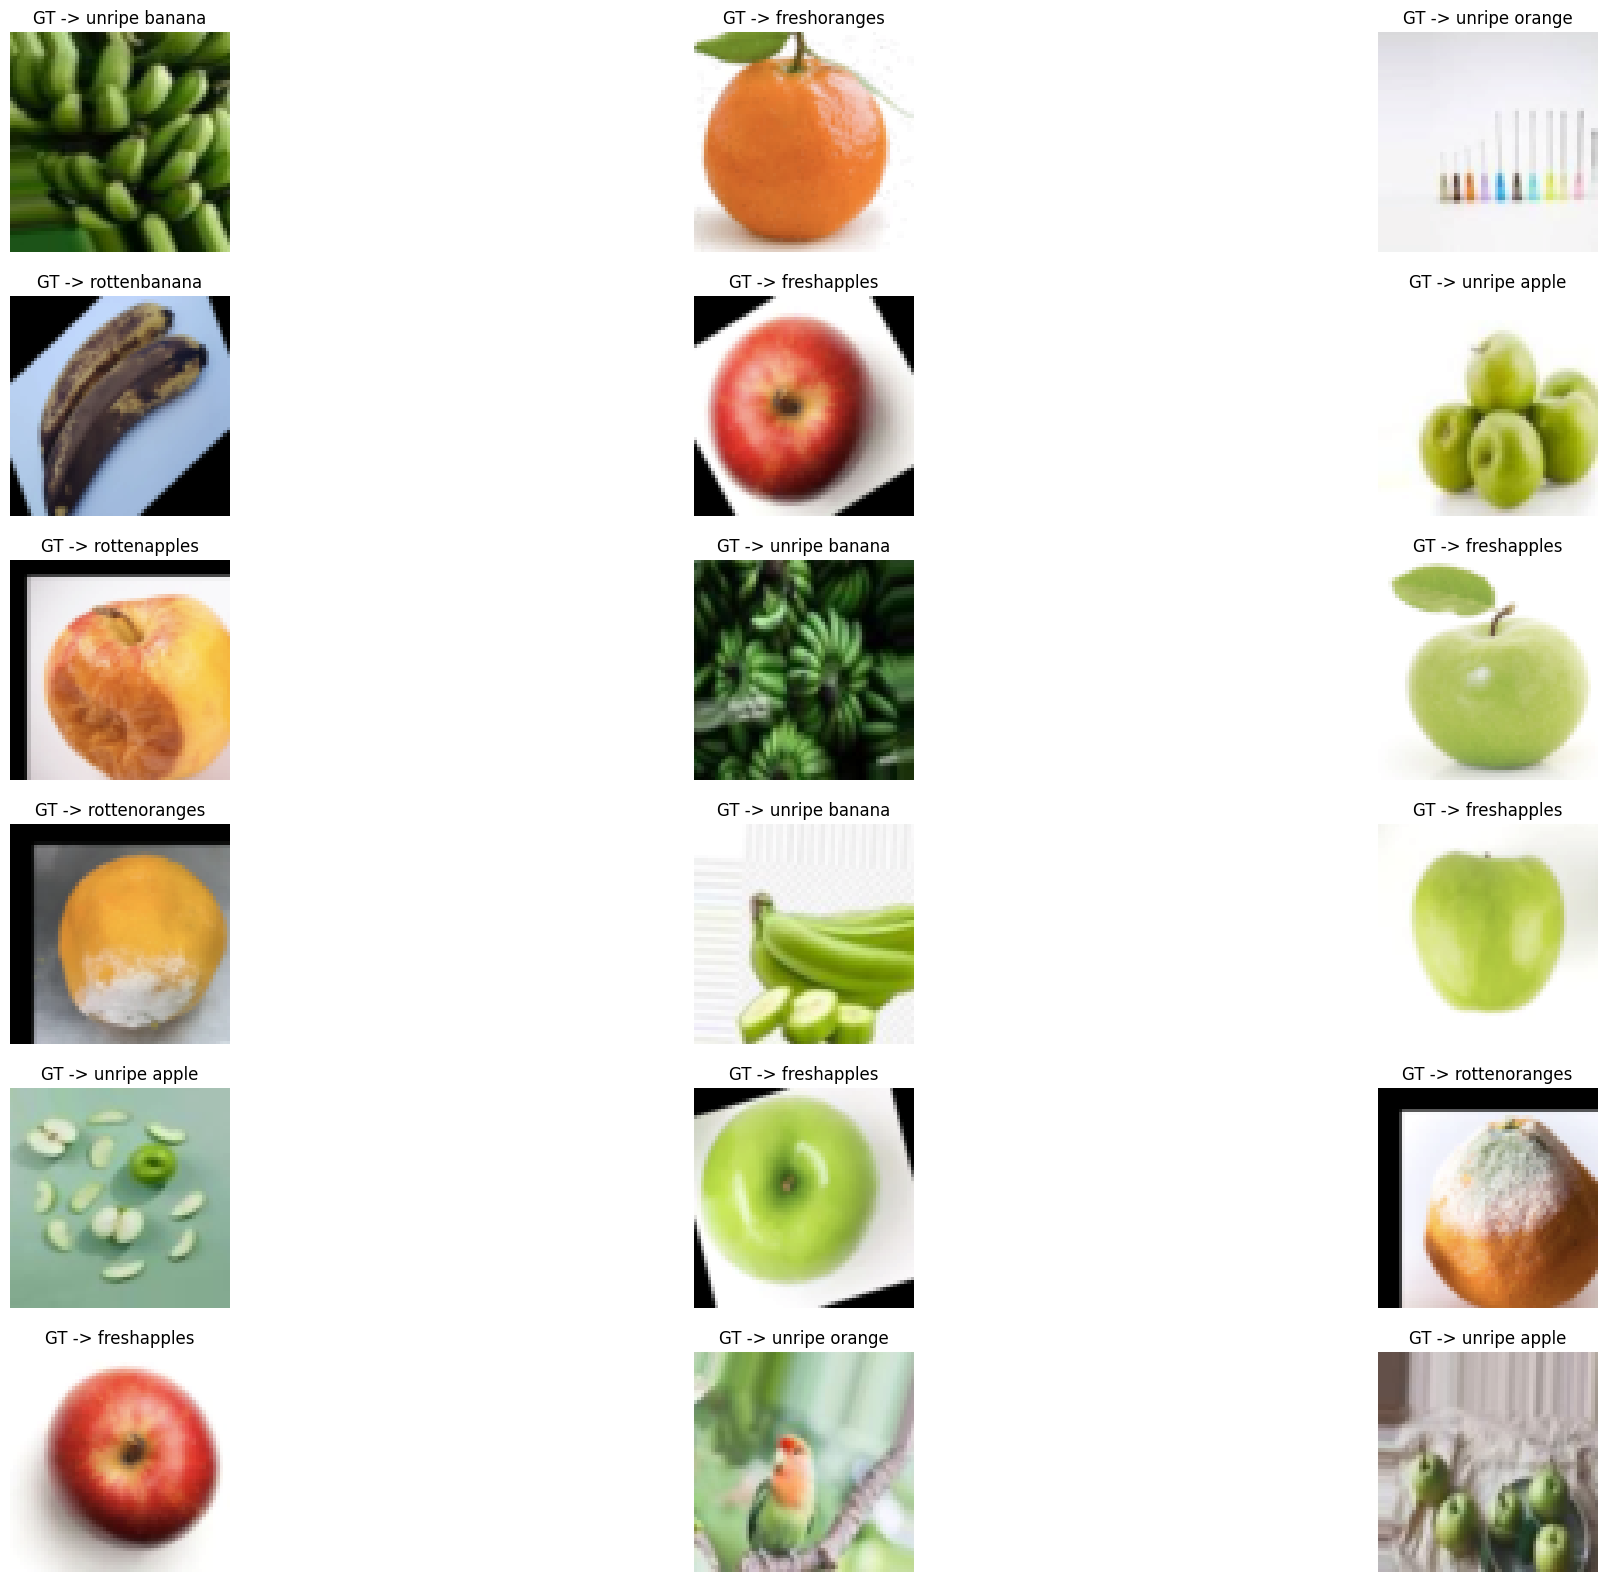

VAL Data Visualization is in process...



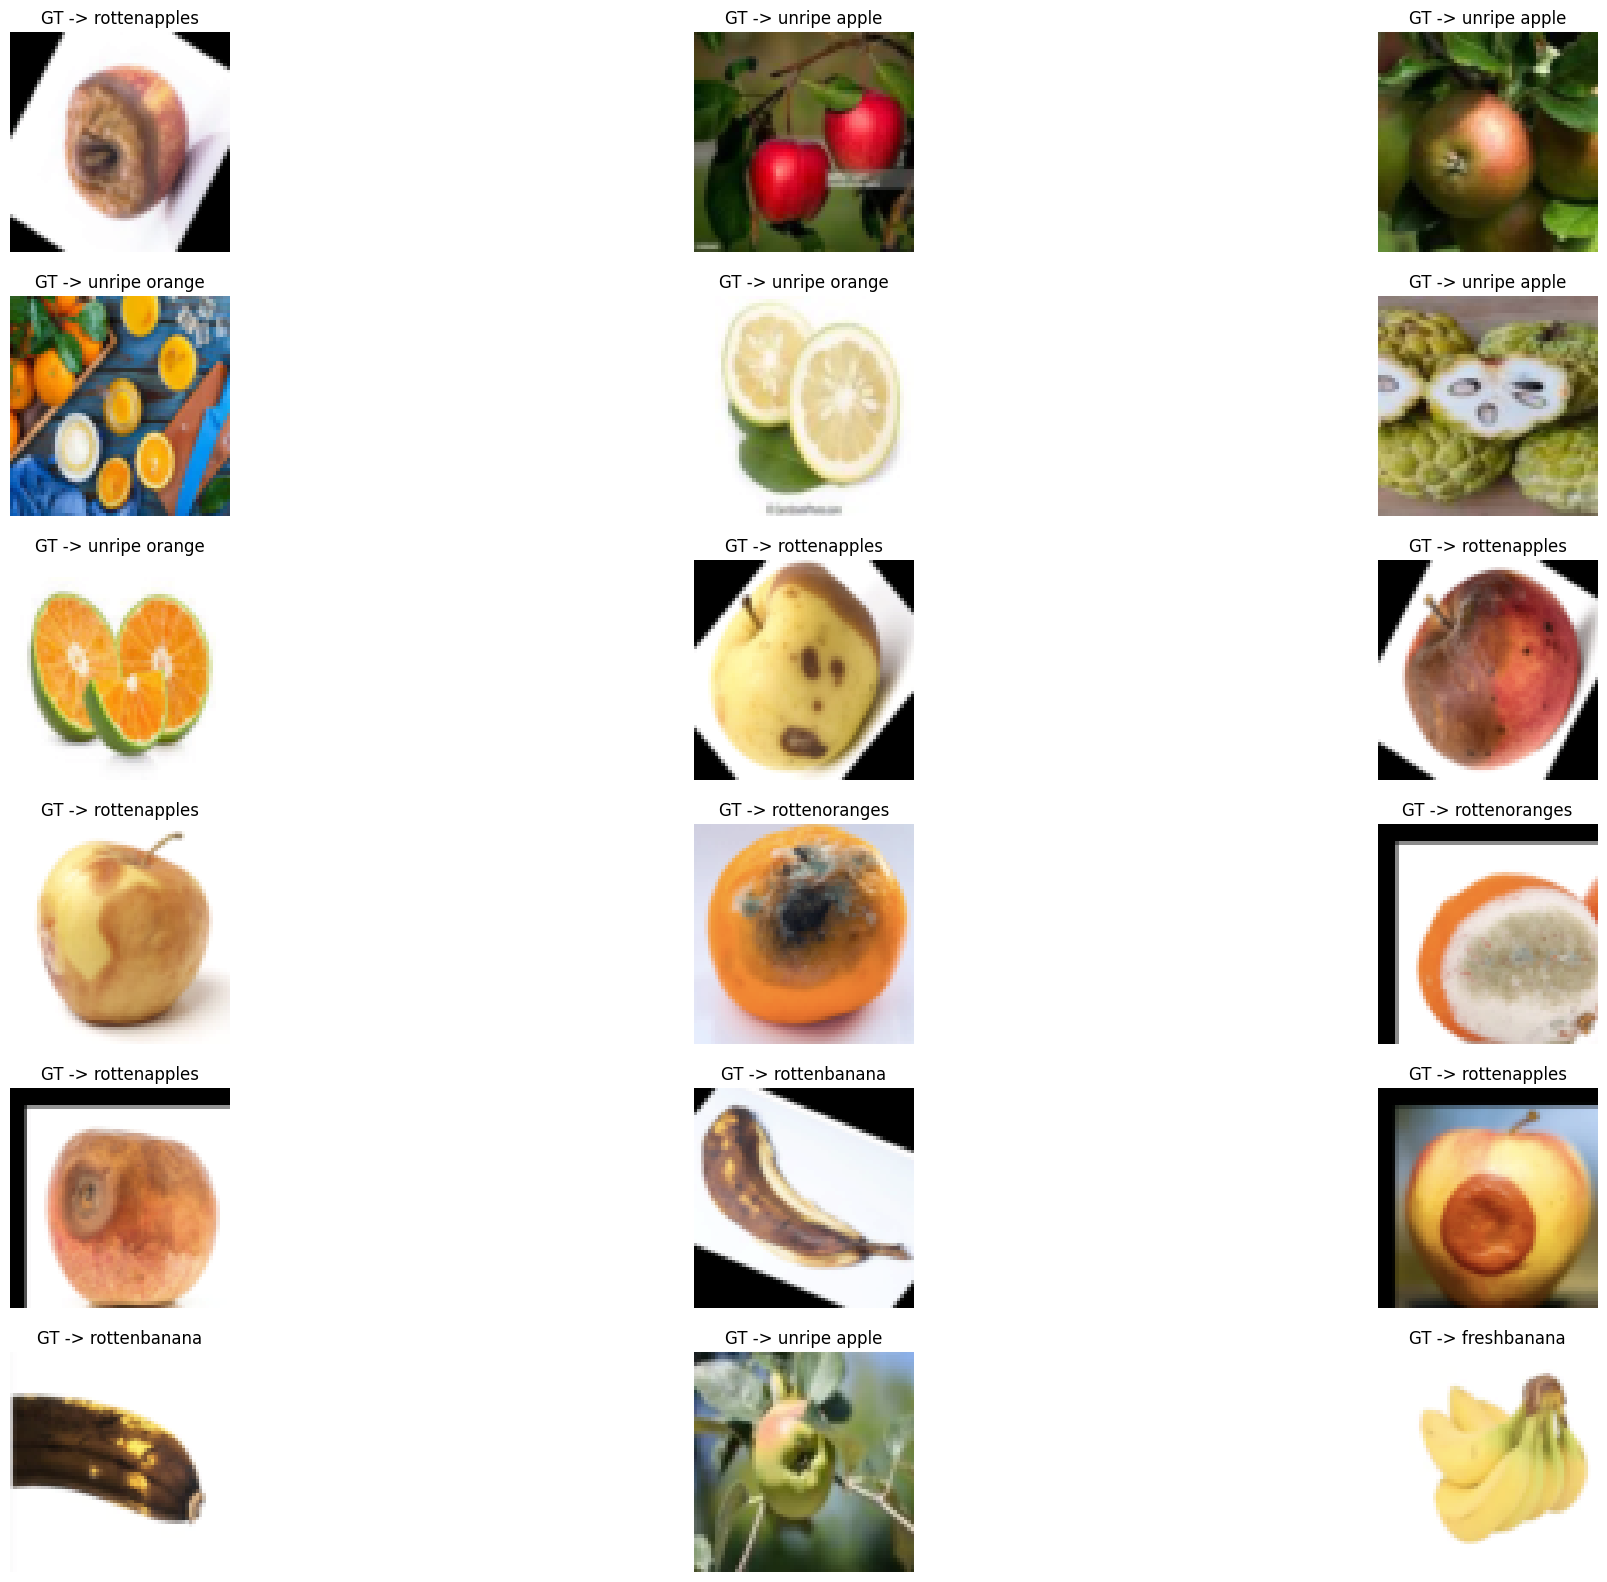

In [ ]:
vis.visualization()

In [ ]:
!pip install torchmetrics timm

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchmetrics
import timm
from tqdm import tqdm

class TrainValidation:
    def __init__(self, model_name, classes, tr_dl, val_dl, device,
                 save_dir="saved_models", save_prefix="model", lr=3e-4,
                 epochs=5, patience=3, threshold=0.01, dev_mode=True):

        self.model_name = model_name
        self.classes = classes
        self.tr_dl = tr_dl
        self.val_dl = val_dl
        self.save_dir = save_dir
        self.save_prefix = save_prefix
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.threshold = threshold
        self.dev_mode = dev_mode
        self.device = device

        self.model = timm.create_model(model_name, pretrained=True, num_classes=len(classes)).to(self.device)
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=len(classes)).to(self.device)

        os.makedirs(save_dir, exist_ok=True)

        self.best_loss = float("inf")
        self.best_acc = 0
        self.not_improved = 0

        self.tr_losses, self.val_losses = [], []
        self.tr_accs, self.val_accs = [], []
        self.tr_f1s, self.val_f1s = [], []

    @staticmethod
    def to_device(batch, device):
        ims, gts = batch
        return ims.to(device), gts.to(device)

    def train_epoch(self):
        self.model.train()
        train_loss, train_acc = 0.0, 0.0
        self.f1_metric.reset()

        for idx, batch in tqdm(enumerate(self.tr_dl), desc="Training"):
            if self.dev_mode and idx >= 5:
                break

            ims, gts = TrainValidation.to_device(batch, device=self.device)
            preds = self.model(ims)
            loss = self.loss_fn(preds, gts)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            train_loss += loss.item()
            train_acc += (torch.argmax(preds, dim=1) == gts).sum().item()
            self.f1_metric.update(preds, gts)

        train_loss /= len(self.tr_dl)
        train_acc /= len(self.tr_dl.dataset)
        train_f1 = self.f1_metric.compute().item()

        self.tr_losses.append(train_loss)
        self.tr_accs.append(train_acc)
        self.tr_f1s.append(train_f1)

        return train_loss, train_acc, train_f1

    def validate_epoch(self):
        self.model.eval()
        val_loss, val_acc = 0.0, 0.0
        self.f1_metric.reset()

        with torch.no_grad():
            for idx, batch in tqdm(enumerate(self.val_dl), desc="Validation"):
                if self.dev_mode and idx >= 5:
                    break

                ims, gts = TrainValidation.to_device(batch, device=self.device)
                preds = self.model(ims)
                loss = self.loss_fn(preds, gts)

                val_loss += loss.item()
                val_acc += (torch.argmax(preds, dim=1) == gts).sum().item()
                self.f1_metric.update(preds, gts)

        val_loss /= len(self.val_dl)
        val_acc /= len(self.val_dl.dataset)
        val_f1 = self.f1_metric.compute().item()

        self.val_losses.append(val_loss)
        self.val_accs.append(val_acc)
        self.val_f1s.append(val_f1)

        return val_loss, val_acc, val_f1

    def save_best_model(self, val_f1, val_loss):
        if val_f1 > self.best_acc + self.threshold:
            self.best_acc = val_f1
            save_path = os.path.join(self.save_dir, f"{self.save_prefix}_best_model.pth")
            torch.save(self.model.state_dict(), save_path)
            print(f"Best model saved with F1-Score: {self.best_acc:.3f}")
            self.not_improved = 0
        else:
            self.not_improved += 1
            print(f"No improvement for {self.not_improved} epoch(s).")

    def verbose(self, epoch, metric1, metric2, metric3, process="train"):
        print(f"{epoch + 1}-epoch {process} process is completed!")
        print(f"Loss     : {metric1:.3f}")
        print(f"Accuracy : {metric2:.3f}")
        print(f"F1-Score : {metric3:.3f}\n")

    def run(self):
        print("Start training...\n")
        for epoch in range(self.epochs):
            if self.dev_mode and epoch >= 5:
                break

            print(f"Epoch {epoch + 1}/{self.epochs}")
            train_loss, train_acc, train_f1 = self.train_epoch()
            self.verbose(epoch, train_loss, train_acc, train_f1, process="train")

            val_loss, val_acc, val_f1 = self.validate_epoch()
            self.verbose(epoch, val_loss, val_acc, val_f1, process="validation")

            self.save_best_model(val_f1, val_loss)

            if self.not_improved >= self.patience:
                print("Early stopping triggered.")
                break

# ------------------- USAGE EXAMPLE -------------------

# Assume your dataset and dataloaders are ready
# from your_dataset import train_dataset, val_dataset

# Reduce dataset size for debug (optional)
# subset_indices = list(range(100))
# train_dataset = Subset(train_dataset, subset_indices)
# val_dataset = Subset(val_dataset, subset_indices)

# Define your dataloaders
# tr_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_dl = DataLoader(val_dataset, batch_size=32)

# Define class names
# classes = ['class1', 'class2', ..., 'classN']

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "resnet18"         # Use lighter model for faster execution
save_prefix = "fruits"
save_dir = "saved_models"

trainer = TrainValidation(
    model_name=model_name,
    classes=classes,
    tr_dl=tr_dl,
    val_dl=val_dl,
    device=device,
    save_prefix=save_prefix,
    save_dir=save_dir,
    dev_mode=False,       # <-- Full training mode
    epochs=5            # <-- Full 10 epochs
)

trainer.run()

Start training...

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training: 961it [17:15,  1.

1-epoch train process is completed!
Loss     : 0.479
Accuracy : 0.835
F1-Score : 0.835




Validation: 107it [00:40,  2.63it/s]


1-epoch validation process is completed!
Loss     : 0.120
Accuracy : 0.956
F1-Score : 0.956

Best model saved with F1-Score: 0.956
Epoch 2/5


...

4-epoch validation process is completed!
Loss     : 0.026
Accuracy : 0.992
F1-Score : 0.992

No improvement for 2 epoch(s).
Epoch 5/5



Training: 961it [17:32,  1.09s/it]

5-epoch train process is completed!
Loss     : 0.023
Accuracy : 0.993
F1-Score : 0.993




Validation: 107it [00:43,  2.47it/s]

5-epoch validation process is completed!
Loss     : 0.016
Accuracy : 0.995
F1-Score : 0.995

No improvement for 3 epoch(s).
Early stopping triggered.


**Learning Curves**

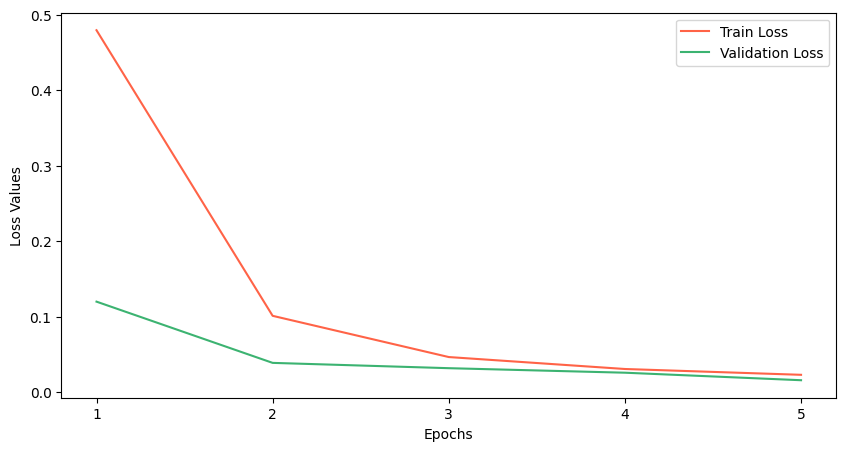

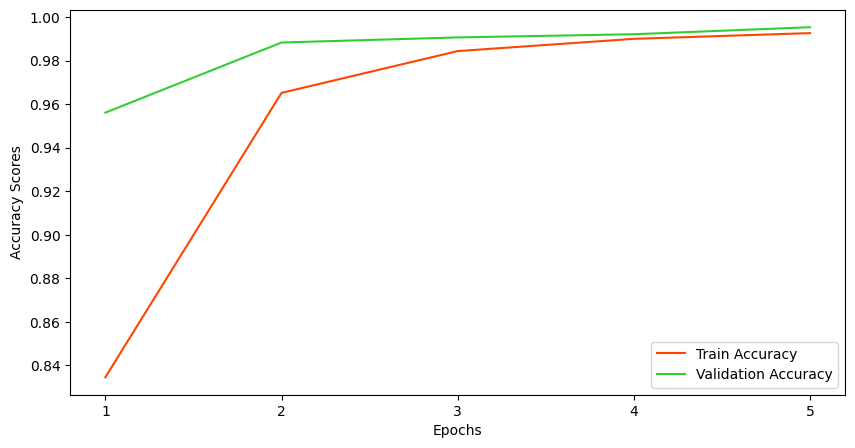

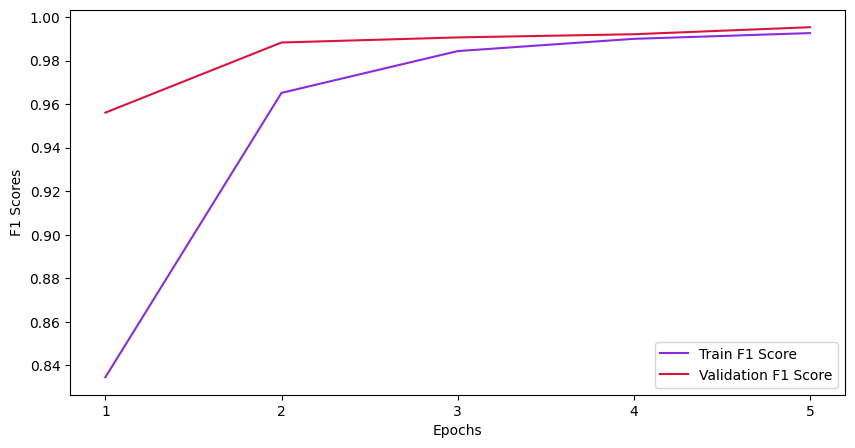

In [ ]:
class PlotLearningCurves:

    def __init__(self, tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s):

        self.tr_losses, self.val_losses, self.tr_accs, self.val_accs, self.tr_f1s, self.val_f1s = tr_losses, val_losses, tr_accs, val_accs, tr_f1s, val_f1s

    def plot(self, array_1, array_2, label_1, label_2, color_1, color_2):

        plt.plot(array_1, label = label_1, c = color_1)
        plt.plot(array_2, label = label_2, c = color_2)

    def create_figure(self):
        plt.figure(figsize = (10, 5))

    def decorate(self, ylabel, xlabel = "Epochs"):

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xticks(ticks = np.arange(len(self.tr_accs)), labels = [i for i in range(1, len(self.tr_accs) + 1)])
        plt.legend()
        plt.show()

    def visualize(self):

        # Figure 1: Loss Curves with more colorful colors
        self.create_figure()
        self.plot(array_1 = self.tr_losses, array_2 = self.val_losses, label_1 = "Train Loss", label_2 = "Validation Loss", color_1 = "#FF6347", color_2 = "#3CB371")  # Tomato and MediumSeaGreen
        self.decorate(ylabel = "Loss Values")

        # Figure 2: Accuracy Curves with more colorful colors
        self.create_figure()
        self.plot(array_1 = self.tr_accs, array_2 = self.val_accs, label_1 = "Train Accuracy", label_2 = "Validation Accuracy", color_1 = "#FF4500", color_2 = "#32CD32")  # OrangeRed and LimeGreen
        self.decorate(ylabel = "Accuracy Scores")

        # Figure 3: F1 Score Curves with more colorful colors
        self.create_figure()
        self.plot(array_1 = self.tr_f1s, array_2 = self.val_f1s, label_1 = "Train F1 Score", label_2 = "Validation F1 Score", color_1 = "#8A2BE2", color_2 = "#DC143C")  # BlueViolet and Crimson
        self.decorate(ylabel = "F1 Scores")

PlotLearningCurves(tr_losses=trainer.tr_losses, val_losses=trainer.val_losses, tr_accs=trainer.tr_accs, val_accs=trainer.val_accs, tr_f1s=trainer.tr_f1s, val_f1s=trainer.val_f1s).visualize()

***Inference and AI Model Performance Analysis with GradCAM ***

In [ ]:
!pip install grad-cam
!pip install grad-cam opencv-python seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=9339ca752495f9992fa6d8d12aeb0fcb67ff480b984fa92a098f89ae78f561d6
  Stored in directory: /root/.cache/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Inference: 7778it [03:34, 36.26it/s]


Accuracy of the model on the test data -> 0.978


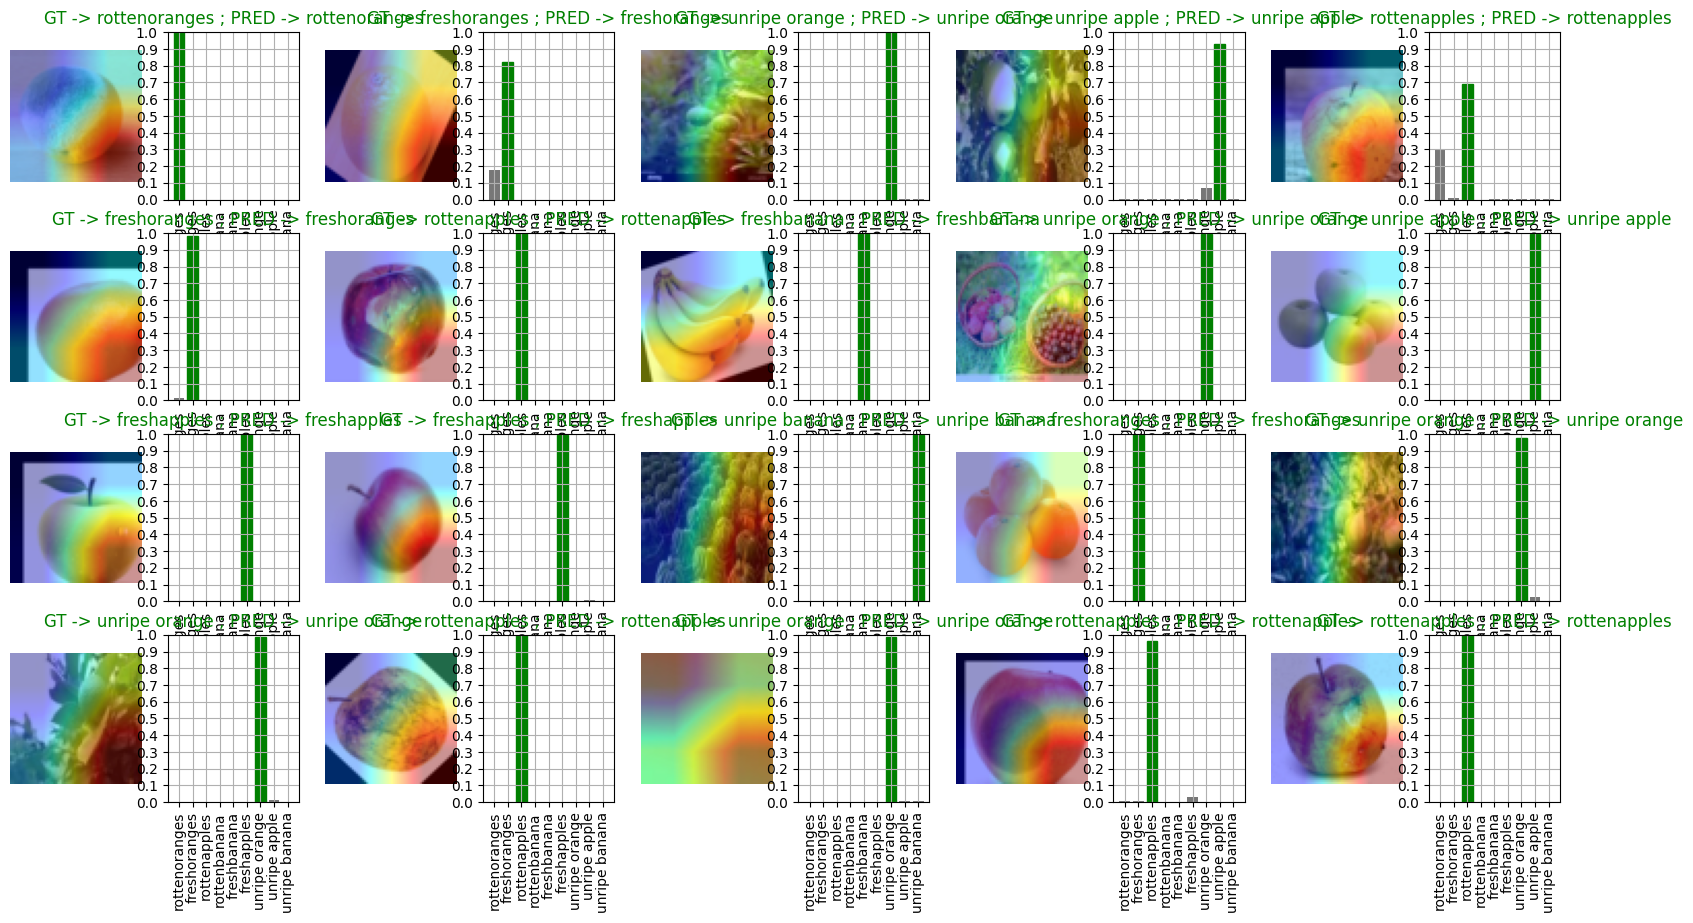

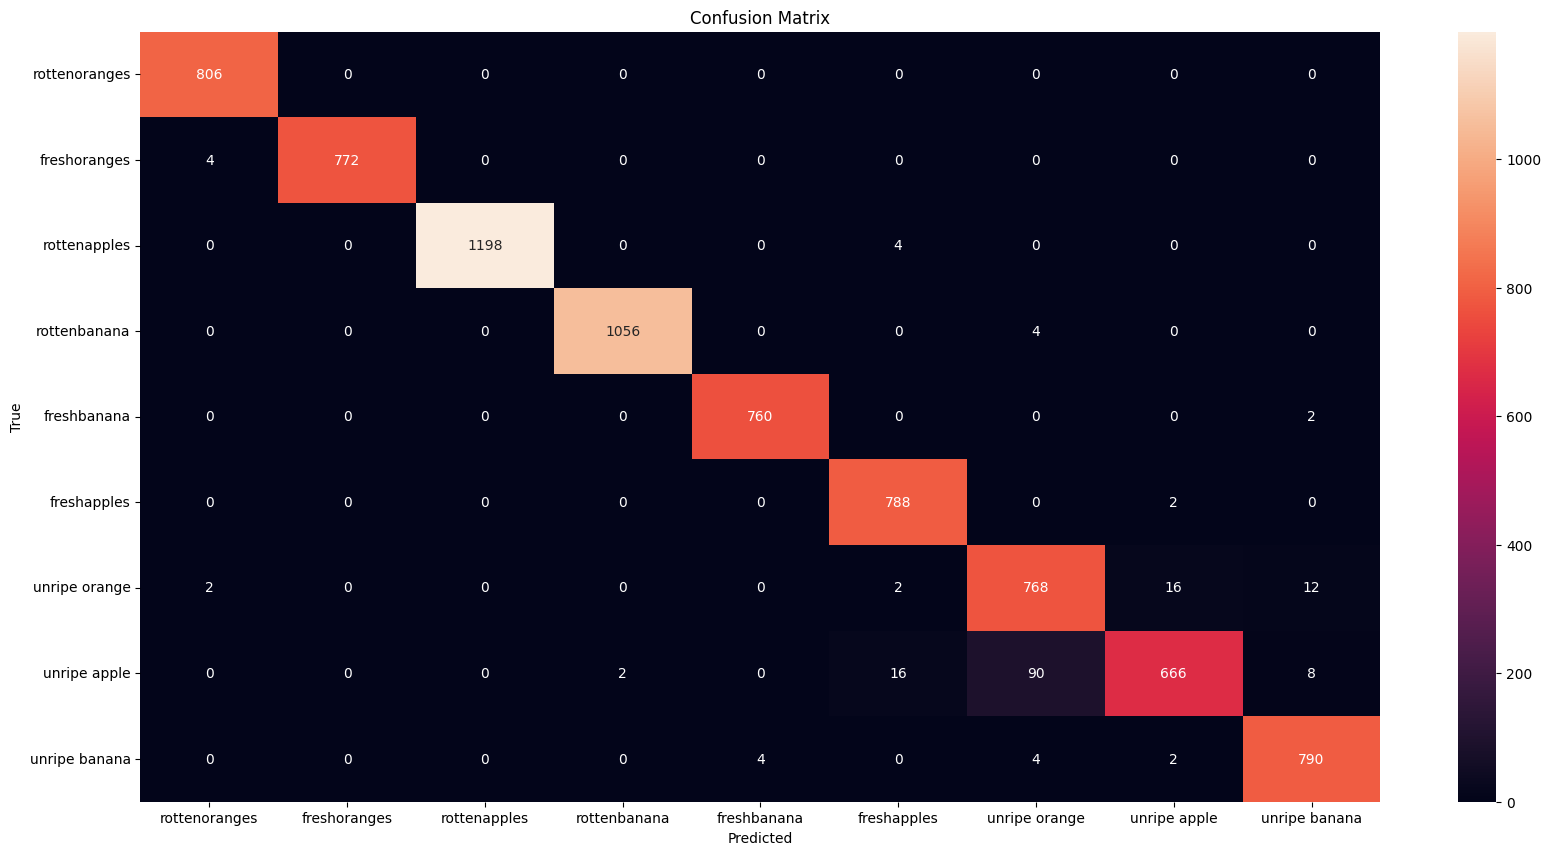

In [ ]:
from pytorch_grad_cam import GradCAM
import cv2, random
import seaborn as sns
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import torch
import numpy as np # Added import for numpy
import matplotlib.pyplot as plt # Added import for matplotlib
import torch.nn as nn # Added import for nn
import timm # Added import for timm
from torch.utils.data import DataLoader # Added import for DataLoader
from torchvision import transforms as T # Added import for transforms

class Denormalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Reverse the normalization applied to the image tensor.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

class ModelInferenceVisualizer:
    def __init__(self, model, device, class_names=None, im_size=224, mean = mean, std = std):

        self.denormalize = Denormalize(mean, std)
        self.model = model
        self.device = device
        self.class_names = class_names
        self.im_size = im_size
        self.model.eval()  # Set model to evaluation mode

    def tensor_to_image(self, tensor):
        """
        Convert a normalized tensor to a denormalized image array.
        """
        tensor = self.denormalize(tensor)  # Denormalize the tensor
        tensor = tensor.permute(1, 2, 0)  # Convert from CxHxW to HxWxC
        return (tensor.cpu().numpy() * 255).astype(np.uint8)

    def plot_value_array(self, logits, gt, class_names):
        """Plot the prediction probability array."""
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1)

        plt.grid(visible=True)
        plt.xticks(range(len(class_names)), class_names, rotation='vertical')
        plt.yticks(np.arange(0.0, 1.1, 0.1))
        bars = plt.bar(range(len(class_names)), [p.item() for p in probs[0]], color="#777777")
        plt.ylim([0, 1])
        if pred_class.item() == gt:
            bars[pred_class].set_color('green')
        else:
            bars[pred_class].set_color('red')

    def generate_cam_visualization(self, image_tensor):
        """Generate GradCAM visualization."""
        # For ResNet, the last convolutional layer is typically in the 'layer4' block.
        # We select the last module within the last layer block.
        target_layers = [self.model.layer4[-1]] # Correct target layer for ResNet18
        cam = GradCAMPlusPlus(model=self.model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0))[0, :]
        return grayscale_cam

    def infer_and_visualize(self, test_dl, num_images=5, rows=2):
        """Perform inference and visualize predictions along with GradCAM."""
        preds, images, lbls, logitss = [], [], [], []
        accuracy, count = 0, 1

        with torch.no_grad():
            for idx, batch in tqdm(enumerate(test_dl), desc="Inference"):
                # if idx == 20: break
                im, gt = TrainValidation.to_device(batch, device = self.device) # Assuming TrainValidation.to_device is defined elsewhere
                logits = self.model(im)
                pred_class = torch.argmax(logits, dim=1)
                accuracy += (pred_class == gt).sum().item()
                images.append(im[0])
                logitss.append(logits[0])
                preds.append(pred_class[0].item())
                lbls.append(gt[0].item())

        print(f"Accuracy of the model on the test data -> {(accuracy / len(test_dl.dataset)):.3f}")

        plt.figure(figsize=(20, 10))
        indices = [random.randint(0, len(images) - 1) for _ in range(num_images)]
        for idx, index in enumerate(indices):
            # Convert and denormalize image
            im = self.tensor_to_image(images[index].squeeze())
            pred_idx = preds[index]
            gt_idx = lbls[index]

            # Display image
            plt.subplot(rows, 2 * num_images // rows, count)
            count += 1
            plt.imshow(im, cmap="gray")
            plt.axis("off")

            # GradCAM visualization
            grayscale_cam = self.generate_cam_visualization(images[index])
            visualization = show_cam_on_image(im / 255, grayscale_cam, image_weight=0.4, use_rgb=True)
            plt.imshow(cv2.resize(visualization, (self.im_size, self.im_size), interpolation=cv2.INTER_LINEAR), alpha=0.7, cmap='jet')
            plt.axis("off")

            # Prediction probability array
            logits = logitss[index]
            if logits.dim() == 1:  # If 1D, add a batch dimension
                logits = logits.unsqueeze(0)
            plt.subplot(rows, 2 * num_images // rows, count)
            count += 1
            self.plot_value_array(logits=logits, gt=gt_idx, class_names=self.class_names)

            # Title with GT and Prediction
            if self.class_names:
                gt_name = self.class_names[gt_idx]
                pred_name = self.class_names[pred_idx]
                color = "green" if gt_name == pred_name else "red"
                plt.title(f"GT -> {gt_name} ; PRED -> {pred_name}", color=color)

        # Plot confusion matrix
        plt.figure(figsize=(20, 10))
        cm = confusion_matrix(lbls, preds)
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()



# Re-instantiate the model and load state dict
model = timm.create_model(model_name = model_name, pretrained = False, num_classes = len(classes)).to(device)
model.load_state_dict(torch.load(f"{save_dir}/{save_prefix}_best_model.pth"))

inference_visualizer = ModelInferenceVisualizer(
    model=model,
    device=device,
    class_names=list(classes.keys()),  # List of class names
    im_size=im_size,
    mean=mean, # Pass mean and std
    std=std # Pass mean and std
)

inference_visualizer.infer_and_visualize(ts_dl, num_images = 20, rows = 4)

**VGG16**

In [ ]:
# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import from tensorflow.keras
from keras.models import Sequential,  Model, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import optimizers
from keras.applications.inception_v3 import InceptionV3

from tensorflow.keras.preprocessing.image import load_img # Import from tensorflow.keras
from tensorflow.keras.preprocessing.image import img_to_array # Import from tensorflow.keras

# model evaluation libraries
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from mlxtend.plotting import plot_confusion_matrix

In [ ]:
# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import from tensorflow.keras
from keras.models import Sequential,  Model, load_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import optimizers
from keras.applications.inception_v3 import InceptionV3

from tensorflow.keras.preprocessing.image import load_img # Import from tensorflow.keras
from tensorflow.keras.preprocessing.image import img_to_array # Import from tensorflow.keras

# model evaluation libraries
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from mlxtend.plotting import plot_confusion_matrix

# Import os module for path manipulation
import os
# Import numpy for path manipulation
import numpy as np


# generating training set

print("training data :")
train_datagen= ImageDataGenerator(rescale=1/255, zoom_range=0.3, rotation_range=50,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   horizontal_flip=True, fill_mode='nearest')


try:
    # Check if the dataset is a Subset and access the original dataset if it is
    # Added a check to see if tr_dl and ts_dl are defined
    # NOTE: Ensure the previous cell creating tr_dl and ts_dl has been run.
    if 'tr_dl' not in locals() and 'tr_dl' not in globals():
        raise NameError("tr_dl is not defined. Please run the cell that creates the PyTorch DataLoaders first.")
    if 'ts_dl' not in locals() and 'ts_dl' not in globals():
        raise NameError("ts_dl is not defined. Please run the cell that creates the PyTorch DataLoaders first.")

    tr_ds_original = tr_dl.dataset.dataset if isinstance(tr_dl.dataset, Subset) else tr_dl.dataset
    ts_ds_original = ts_dl.dataset.dataset if isinstance(ts_dl.dataset, Subset) else ts_dl.dataset

except NameError as e:
    print(f"Error: {e}")
    print("Please ensure the cell creating the CustomDataset and DataLoaders has been run.")
    # Exit or handle the error as appropriate for your notebook environment
    # In a notebook, simply printing the error and stopping execution might be sufficient.
    # You might also want to set flags to skip the rest of the cell or subsequent cells
    # that depend on these variables.
    # For now, we will raise the error to stop execution.
    raise


# Find the unique parent directories for train and test images
# Extract directory names from the image paths found by the CustomDataset
# Access im_paths from the original dataset object
train_image_dirs = set([os.path.dirname(p) for p in tr_ds_original.im_paths])
test_image_dirs = set([os.path.dirname(p) for p in ts_ds_original.im_paths])


# Assuming all images for train are under one root directory and all for test are under another
# We'll find the common prefix of all training directories and testing directories.
# This common prefix will serve as the base directory for flow_from_directory.
if len(train_image_dirs) > 0:
    common_train_prefix = os.path.commonpath(list(train_image_dirs))
    training_dir = common_train_prefix
    print(f"Inferred training data directory: {training_dir}")
else:
    raise ValueError("No training image directories found by the PyTorch dataset. Check CustomDataset logic.")


if len(test_image_dirs) > 0:
    common_test_prefix = os.path.commonpath(list(test_image_dirs))
    testing_dir = common_test_prefix
    print(f"Inferred testing data directory: {testing_dir}")
else:
    # It's possible the test dataset is empty, as warned by CustomDataset.get_dls
    print("No testing image directories found by the PyTorch dataset. Test data loading might fail.")
    # Set testing_dir to a non-existent path as a fallback if no test data is found,
    # which might cause issues later if test_data is used. Consider skipping Keras test/val steps
    # if test_ds is truly empty.
    testing_dir = "/path/to/nonexistent/test_data_fallback"


# Add a print statement to verify the inferred path
print(f"Looking for training data in: {training_dir}")
# Removed the !ls {path} as it's not the correct directory

# --- End of Suggested Changes ---


train_data= train_datagen.flow_from_directory(training_dir,
                                              target_size= (100,100),
                                              batch_size=20,
                                              class_mode= "binary", # Or 'categorical' depending on your dataset classes
                                              shuffle= True)


# generating validation set
print("\nvalidation data :")
val_datagen= ImageDataGenerator(rescale=1/255) # data augmentation is applied only to training data not to validation & test data

# Use the testing_dir for validation as well, assuming it contains class subdirectories.
# Note: flow_from_directory can split a directory into train/validation subsets using
# validation_split and subset arguments. If you have a dedicated validation folder,
# adjust this path accordingly. If not, using the test data for validation is a common
# practice, though not ideal.
val_data= val_datagen.flow_from_directory(testing_dir,
                                          target_size= (100,100),
                                          batch_size=20,
                                          class_mode= "binary", # Match the class_mode with train_data
                                          shuffle= False) # Do not shuffle validation data


# generating test set
print("\ntest data :")
test_datagen= ImageDataGenerator(rescale=1/255)

# Use the same testing_dir for the test set.
# Note: If val_data is also using testing_dir, val_data and test_data will load
# the same images unless you implement a manual split or use flow_from_directory's
# subset argument if your dataset structure supports it.
test_data= test_datagen.flow_from_directory(testing_dir,
                                            target_size= (100,100),
                                            batch_size=20,
                                            class_mode= "binary", # Match the class_mode
                                            shuffle= False) # Do not shuffle test data

training data :
Inferred training data directory: /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/1/archive (1)/dataset
Inferred testing data directory: /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/1/archive (1)/dataset
Looking for training data in: /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/1/archive (1)/dataset
Found 41936 images belonging to 3 classes.

validation data :
Found 41936 images belonging to 3 classes.

test data :
Found 41936 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import VGG16 # Import VGG16 from tensorflow.keras.applications

INPUT_SHAPE = (100, 100, 3) # Define INPUT_SHAPE with image dimensions and color channels

vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

In [ ]:
for layer in vgg_model.layers[:-4]:
    layer.trainable = False

In [ ]:
model_2=Sequential()

model_2.add(Conv2D(64, (3,3), activation='relu', input_shape=INPUT_SHAPE))
model_2.add(MaxPooling2D(2, 2))
model_2.add(Dropout(.2))
model_2.add(Conv2D(128, (3,3), activation='relu'))
model_2.add(MaxPooling2D(2, 2))
model_2.add(Dropout(.2))
model_2.add(Conv2D(200, (3,3), activation='relu'))
model_2.add(MaxPooling2D(2,2))
model_2.add(Dropout(.2))
model_2.add(Conv2D(265, (3,3), activation='relu'))
model_2.add(MaxPooling2D(2,2))
model_2.add(Dropout(.5))
model_2.add(Flatten())
model_2.add(Dense(256, activation='relu'))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dropout(0.2))
model_2.add(Dense(1, activation='sigmoid'))
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 98, 98, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 21, 21, 200)    │       230,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 10, 10, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10, 10, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 265)      │       477,265 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 265)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 4, 4, 265)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,085,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,902,234 (7.26 MB)

 Trainable params: 1,902,234 (7.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import RMSprop # Import RMSprop from tensorflow.keras.optimizers
# or
# from tensorflow.keras import optimizers
# and use optimizers.RMSprop


model_2.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=1e-4), # Alternatively, use RMSprop(lr=1e-4) if using tf.keras.optimizers directly
              metrics=['acc'])

In [ ]:
history = model_2.fit(
    train_data,
    epochs=20,
    steps_per_epoch=10,
    validation_data=val_data,
    validation_steps=2
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - acc: 0.2083 - loss: 0.4998 - val_acc: 0.0000e+00 - val_loss: 1.1080
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - acc: 0.0837 - loss: 0.1156 - val_acc: 0.0000e+00 - val_loss: 1.5825
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - acc: 0.1147 - loss: -0.1174 - val_acc: 0.0000e+00 - val_loss: 2.4048
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - acc: 0.1022 - loss: 0.0580 - val_acc: 0.0000e+00 - val_loss: 2.1082
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - acc: 0.0637 - loss: 0.0137 - val_acc: 0.0000e+00 - val_loss: 2.9215
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - acc: 0.0790 - loss: 0.6386 - val_acc: 0.0000e+00 - val_loss: 1.5413
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - acc: 0.0947 - loss: 0.2858 - val_acc: 0.0000e+00 - val_loss: 1.2745
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - acc: 0.0431 - loss: 0.5476 - val_acc: 0.0000e+00 - val_loss: 1.0362
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1

Text(0.5, 1.0, 'Accuracy Curves')

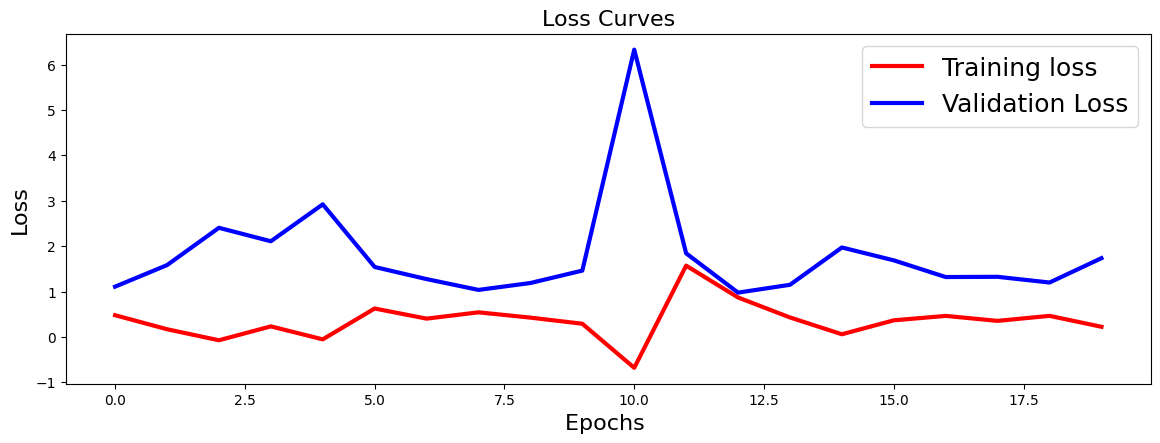

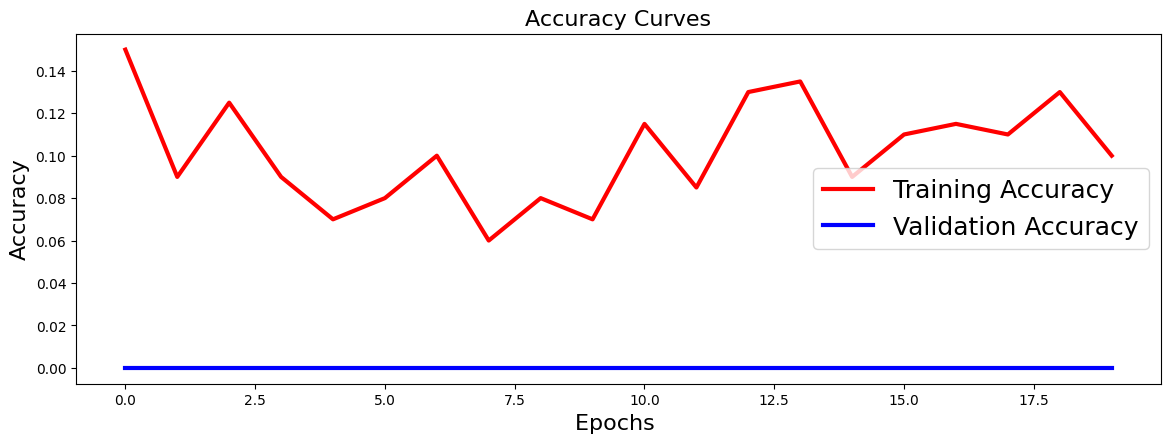

In [ ]:
plt.figure(figsize=[14,10])
plt.subplot(211)
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

# Accuracy Curves
plt.figure(figsize=[14,10])
plt.subplot(212)
plt.plot(history.history['acc'],'r',linewidth=3.0)
plt.plot(history.history['val_acc'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

In [ ]:
prediction = model_2.predict(test_data, steps=int(np.ceil(val_data.samples/val_data.batch_size)), verbose=2)
# The np.ceil function returns a float, which is causing the TypeError.
# Converting the result of np.ceil to an integer using int() should resolve the issue.
prediction= prediction > 0.5
prediction

2097/2097 - 728s - 347ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]])

0.09273655093475773
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     20968
           1       0.09      1.00      0.17      3889
           2       0.00      0.00      0.00     17079

    accuracy                           0.09     41936
   macro avg       0.03      0.33      0.06     41936
weighted avg       0.01      0.09      0.02     41936



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


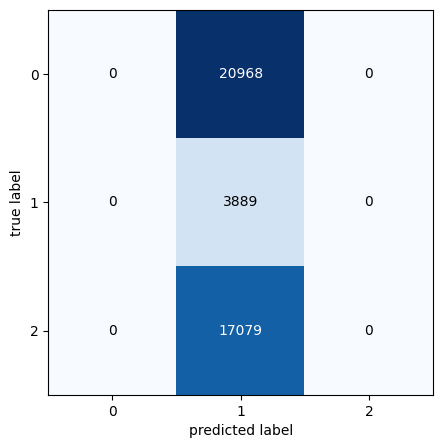

In [ ]:
cm= confusion_matrix(test_data.classes, prediction)
plot_confusion_matrix(cm, figsize=(5,5))

print(accuracy_score(test_data.classes, prediction))
print(classification_report(test_data.classes, prediction))

**CNN**

In [ ]:
from tensorflow.keras.models import Sequential
model_3= Sequential()

model_3.add(Conv2D(filters= 16, kernel_size=(3,3), activation="relu", input_shape=(100, 100, 3)))
model_3.add(MaxPooling2D(pool_size=(2,2)))

model_3.add(Conv2D(filters= 32, kernel_size=(3,3), activation="relu"))
model_3.add(MaxPooling2D(pool_size=(2,2)))

model_3.add(Conv2D(filters= 64, kernel_size=(3,3), activation="relu"))
model_3.add(MaxPooling2D(pool_size=(2,2)))

model_3.add(Conv2D(filters= 128, kernel_size=(3,3), activation="relu"))
model_3.add(MaxPooling2D(pool_size=(2,2)))

model_3.add(Flatten())
model_3.add(Dense(units= 512, activation='relu'))
model_3.add(Dropout(0.2))

model_3.add(Dense(units=1, activation="sigmoid"))

model_3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,147,041 (4.38 MB)

 Trainable params: 1,147,041 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model compiling
model_3.compile(loss= "binary_crossentropy", optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=["accuracy"])

# model fitting - replacing fit_generator with fit
history = model_3.fit(
    train_data,
    epochs=20,
    steps_per_epoch=10,
    validation_data=val_data,
    validation_steps=2
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 365ms/step - accuracy: 0.1741 - loss: 0.4038 - val_accuracy: 0.0000e+00 - val_loss: 2.4318
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 529ms/step - accuracy: 0.0503 - loss: 0.1845 - val_accuracy: 0.0000e+00 - val_loss: 2.9114
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step - accuracy: 0.0665 - loss: 0.6226 - val_accuracy: 0.0000e+00 - val_loss: 2.2469
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 531ms/step - accuracy: 0.0935 - loss: 0.1791 - val_accuracy: 0.0000e+00 - val_loss: 2.5880
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 534ms/step - accuracy: 0.0939 - loss: 0.4643 - val_accuracy: 0.0000e+00 - val_loss: 1.6075
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 540ms/step - accuracy: 0.1053 - loss: 0.2013 - val_accuracy: 0.0000e+00 - val_loss: 1.9149
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.0897 - loss: -0.0200 - val_accuracy: 0.0000e+00 - val_loss: 3.1099
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 525ms/step - accuracy: 0.1539 - lo

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

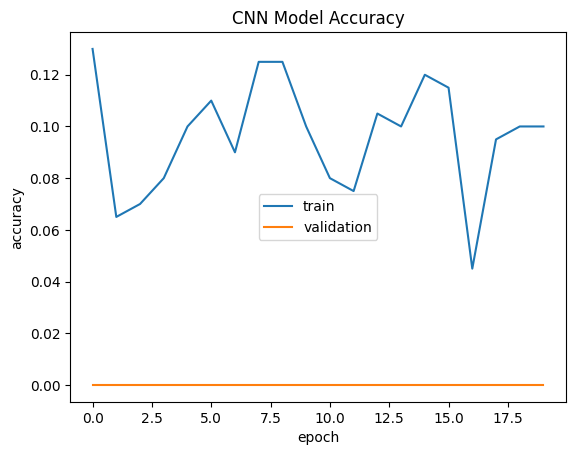

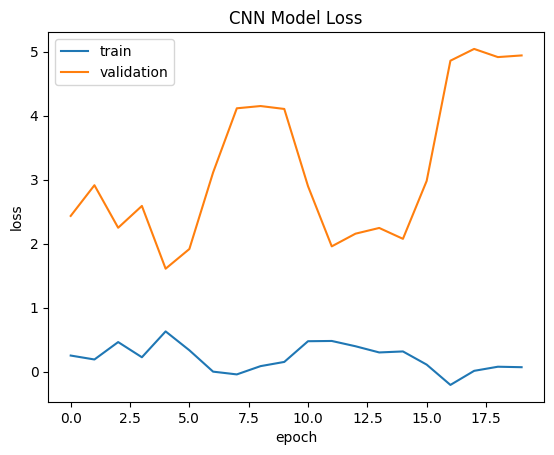

In [ ]:
epochs=Ss range(len(history.history["accuracy"]))
# accuracy plot
plt.plot(epochs, history.history["accuracy"])
plt.plot(epochs, history.history["val_accuracy"])
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("CNN Model Accuracy")
plt.legend(["train", "validation"])
plt.show()

# loss plot
plt.plot(epochs, history.history["loss"])
plt.plot(epochs, history.history["val_loss"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("CNN Model Loss")
plt.legend(["train", "validation"])
plt.show()

In [ ]:
prediction = model_3.predict(test_data, steps=int(np.ceil(val_data.samples/val_data.batch_size)), verbose=2)
# The np.ceil function returns a float, which is causing the TypeError.
# Converting the result of np.ceil to an integer using int() should resolve the issue.
prediction= prediction > 0.5
prediction

2097/2097 - 245s - 117ms/step


array([[ True],
       [ True],
       [ True],
       ...,
       [ True],
       [ True],
       [ True]])

0.09273655093475773
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     20968
           1       0.09      1.00      0.17      3889
           2       0.00      0.00      0.00     17079

    accuracy                           0.09     41936
   macro avg       0.03      0.33      0.06     41936
weighted avg       0.01      0.09      0.02     41936



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


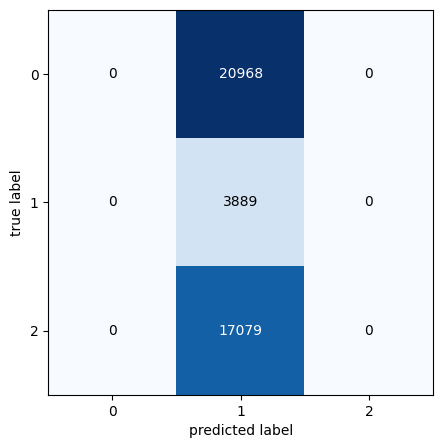

In [ ]:
cm= confusion_matrix(test_data.classes, prediction)
plot_confusion_matrix(cm, figsize=(5,5))

print(accuracy_score(test_data.classes, prediction))
print(classification_report(test_data.classes, prediction))